# SolarShare — Backend Matching Engine (M6)
### Role: Colab/Python Backend Engine · Repo path: `backend/matching_engine.ipynb`

This is the **M6** notebook from the master plan. It implements the exact shared matching procedure and the exact shared hash-chain logic — the same algorithm M5 implements independently in JavaScript — and exports `backend_output.json` for the frontend to fetch.

**Workflow reminder:**
1. `Runtime -> Run all` now, check the output below matches what's printed here.
2. Download `backend_output.json` (appears in the Colab file panel on the left after running) -> save it as `backend/backend_output.json` in the repo.
3. Save this notebook itself as `backend/matching_engine.ipynb`.
4. Commit + push.
5. Hour 6: compare your matched pairs against M5's — they should be identical households/kWh/prices (see note near the bottom about hashes specifically).
6. Hour 10: `Restart and run all` once, confirm 0 errors.
7. 15–20 min before presenting: run once more for a fresh session.
8. Keep this tab open on the demo laptop during the live pitch — it's Q&A backup, not the on-stage demo itself.

In [1]:
# Well-commented per the plan — this may be shown live to judges.
import hashlib
import json
import networkx as nx
import matplotlib.pyplot as plt
from datetime import datetime, timezone

## 1. The shared dataset

Exactly the 5 users from the shared contract — same IDs, same field names, same values M3/M4/M5 are all using.

In [2]:
users = [
    {"id": "U1", "name": "Priya",  "role": "prosumer", "surplus_kwh": 5.0, "asking_price": 6.0},
    {"id": "U2", "name": "Rahul",  "role": "buyer",    "demand_kwh": 3.0, "max_price": 6.5},
    {"id": "U3", "name": "Sanjay", "role": "prosumer", "surplus_kwh": 4.2, "asking_price": 5.8},
    {"id": "U4", "name": "Meera",  "role": "buyer",    "demand_kwh": 2.5, "max_price": 6.0},
    {"id": "U5", "name": "Vikram", "role": "buyer",    "demand_kwh": 3.5, "max_price": 6.2},
]

# keep the untouched originals separate — we need full, un-reduced amounts later for the graph and for listings
raw_sellers = [u for u in users if u["role"] == "prosumer"]
raw_buyers = [u for u in users if u["role"] == "buyer"]

print(f"{len(raw_sellers)} prosumers, {len(raw_buyers)} buyers loaded")

2 prosumers, 3 buyers loaded


## 2. The exact matching procedure

Do not swap this for a different algorithm — M5 (JavaScript) implements this identical procedure, and the matched pairs must agree between both sides.

1. Sort prosumers by `asking_price` ascending (tie -> `id` ascending).
2. Sort buyers by `max_price` descending (tie -> `id` ascending).
3. For each buyer in that order: find the *cheapest available* seller whose `asking_price <= buyer.max_price`. Trade `min(seller.remaining_kwh, buyer.remaining_demand)`. Reduce both. If the seller still has stock left, they stay available for the next buyer. If no seller qualifies, that buyer is left unmatched.

In [3]:
# working copies that get reduced as trades happen — originals in raw_sellers/raw_buyers stay untouched
sellers = [dict(u, remaining_kwh=u["surplus_kwh"]) for u in raw_sellers]
buyers = [dict(u, remaining_demand=u["demand_kwh"]) for u in raw_buyers]

sellers.sort(key=lambda s: (s["asking_price"], s["id"]))   # step a
buyers.sort(key=lambda b: (-b["max_price"], b["id"]))       # step b

matches = []
for buyer in buyers:                                                            # step c
    eligible = [s for s in sellers if s["remaining_kwh"] > 0 and s["asking_price"] <= buyer["max_price"]]
    if not eligible:
        print(f"{buyer['name']} ({buyer['id']}): no eligible seller -> stays unmatched")
        continue                                                                # step e
    seller = min(eligible, key=lambda s: (s["asking_price"], s["id"]))          # cheapest available
    kwh_traded = round(min(seller["remaining_kwh"], buyer["remaining_demand"]), 2)
    seller["remaining_kwh"] = round(seller["remaining_kwh"] - kwh_traded, 2)    # step c (reduce)
    buyer["remaining_demand"] = round(buyer["remaining_demand"] - kwh_traded, 2)
    print(f"{buyer['name']} ({buyer['id']}) <- {seller['name']} ({seller['id']}): {kwh_traded} kWh @ Rs.{seller['asking_price']}")
    matches.append({"seller": dict(seller), "buyer": dict(buyer), "kwh_traded": kwh_traded, "price_per_kwh": seller["asking_price"]})

print(f"\n{len(matches)} matches found, {len(buyers) - len(matches)} buyer(s) unmatched")

Rahul (U2) <- Sanjay (U3): 3.0 kWh @ Rs.5.8
Vikram (U5) <- Sanjay (U3): 1.2 kWh @ Rs.5.8
Meera (U4) <- Priya (U1): 2.5 kWh @ Rs.6.0

3 matches found, 0 buyer(s) unmatched


## 3. Graph visualization (compatibility view)

Nodes = every user. An edge means a prosumer-buyer pair is *compatible* (`asking_price <= max_price`) — this is a visual aid, separate from which trades actually got picked above.

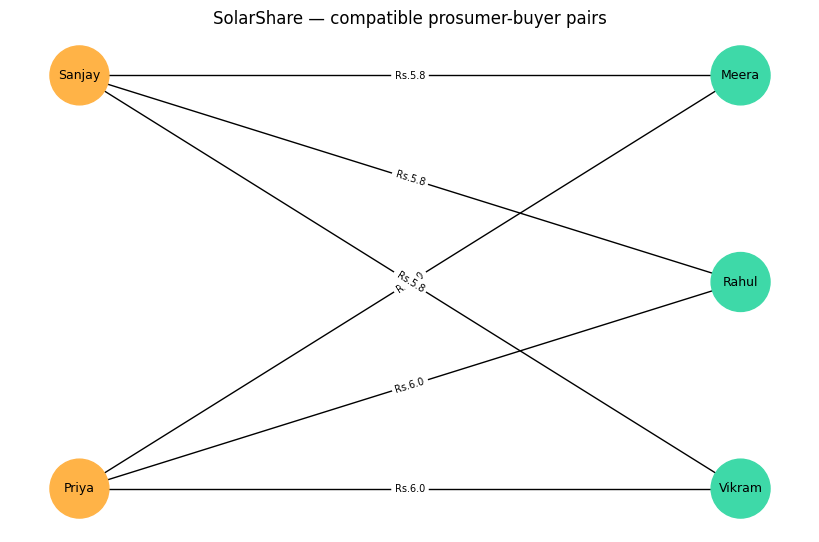

In [4]:
G = nx.Graph()
for u in users:
    G.add_node(u["id"], label=u["name"], role=u["role"])
for s in raw_sellers:
    for b in raw_buyers:
        if s["asking_price"] <= b["max_price"]:
            G.add_edge(s["id"], b["id"], weight=s["asking_price"])

pos = nx.bipartite_layout(G, [s["id"] for s in raw_sellers])
node_colors = ["#FFB347" if G.nodes[n]["role"] == "prosumer" else "#3ED9A8" for n in G.nodes]  # matches app's amber/teal palette
labels = {u["id"]: u["name"] for u in users}
edge_labels = {(u, v): f"Rs.{d['weight']}" for u, v, d in G.edges(data=True)}

plt.figure(figsize=(8, 5))
nx.draw(G, pos, with_labels=True, labels=labels, node_color=node_colors, node_size=1800, font_size=9)
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7)
plt.title("SolarShare — compatible prosumer-buyer pairs")
plt.axis('off')
plt.show()

## 4 & 5. Trade records + the exact hash chain

Same hash formula as the shared contract: `SHA256(JSON.stringify(trade_without_hash) + previous_hash)`. In Python that's `json.dumps(trade_data, sort_keys=True)` — starting `previous_hash` is the literal string `"0000000000000000"`, same as M5's JS.

**Heads-up for the Hour-6 comparison with M5:** the *matched pairs* (who trades with whom, how much, at what price) should come out identical on both sides — same data, same deterministic procedure. The hash *strings* themselves don't need to match character-for-character between JS and Python — `JSON.stringify` and `json.dumps(sort_keys=True)` don't guarantee the same key order, so each side's hash chain is only required to be internally consistent, not identical to the other side's.

In [5]:
def generate_hash(trade_data, previous_hash):
    combined = json.dumps(trade_data, sort_keys=True) + previous_hash
    return hashlib.sha256(combined.encode()).hexdigest()

last_hash = "0000000000000000"
trades = []
for i, m in enumerate(matches, start=1):
    trade_data = {
        "trade_id": f"T{i}",
        "seller_id": m["seller"]["id"],
        "buyer_id": m["buyer"]["id"],
        "kwh_traded": m["kwh_traded"],
        "price_per_kwh": m["price_per_kwh"],
        "timestamp": datetime.now(timezone.utc).isoformat(),
        "previous_hash": last_hash,
    }
    trade_hash = generate_hash(trade_data, last_hash)
    trade_data["hash"] = trade_hash
    trades.append(trade_data)
    last_hash = trade_hash

print(f"{len(trades)} trades hashed and chained")

3 trades hashed and chained


In [6]:
# 6. Summary table — kWh, price, and hash (first 12 chars), plus a live chain-integrity check
print(f"{'Trade':6} {'Seller':8} {'Buyer':8} {'kWh':>6} {'Price':>8}  {'Hash (first 12)':16} chain_ok")
prev = "0000000000000000"
for t in trades:
    sname = next(u["name"] for u in users if u["id"] == t["seller_id"])
    bname = next(u["name"] for u in users if u["id"] == t["buyer_id"])
    chain_ok = (t["previous_hash"] == prev)
    print(f"{t['trade_id']:6} {sname:8} {bname:8} {t['kwh_traded']:6.1f} Rs.{t['price_per_kwh']:6.2f}  {t['hash'][:12]:16} {chain_ok}")
    prev = t["hash"]

Trade  Seller   Buyer       kWh    Price  Hash (first 12)  chain_ok
T1     Sanjay   Rahul       3.0 Rs.  5.80  16491257e576     True
T2     Sanjay   Vikram      1.2 Rs.  5.80  92ce4157ec71     True
T3     Priya    Meera       2.5 Rs.  6.00  0f9f02210170     True


## 7. Export `backend_output.json`

`listings` = each prosumer's full, un-reduced surplus (this is what populates the Marketplace screen — matches M5's fallback data exactly, so the app looks identical whether the live fetch succeeds or falls back). `trades` = the matched trades computed above, each with its hash.

In [7]:
listings = []
for idx, s in enumerate(raw_sellers, start=1):
    listings.append({
        "listing_id": f"L{idx}",
        "seller_id": s["id"],
        "kwh_available": s["surplus_kwh"],
        "price_per_kwh": s["asking_price"],
        "status": "open",
    })

output = {"listings": listings, "trades": trades}

with open("backend_output.json", "w") as f:
    json.dump(output, f, indent=2)

print("backend_output.json written. Contents:\n")
print(json.dumps(output, indent=2))

backend_output.json written. Contents:

{
  "listings": [
    {
      "listing_id": "L1",
      "seller_id": "U1",
      "kwh_available": 5.0,
      "price_per_kwh": 6.0,
      "status": "open"
    },
    {
      "listing_id": "L2",
      "seller_id": "U3",
      "kwh_available": 4.2,
      "price_per_kwh": 5.8,
      "status": "open"
    }
  ],
  "trades": [
    {
      "trade_id": "T1",
      "seller_id": "U3",
      "buyer_id": "U2",
      "kwh_traded": 3.0,
      "price_per_kwh": 5.8,
      "timestamp": "2026-08-30T11:51:56.297545+00:00",
      "previous_hash": "0000000000000000",
      "hash": "16491257e576445f6e8f7d9043aaf34b1ef9652174d0629df69dbb4e11e867a4"
    },
    {
      "trade_id": "T2",
      "seller_id": "U3",
      "buyer_id": "U5",
      "kwh_traded": 1.2,
      "price_per_kwh": 5.8,
      "timestamp": "2026-08-30T11:51:56.297680+00:00",
      "previous_hash": "16491257e576445f6e8f7d9043aaf34b1ef9652174d0629df69dbb4e11e867a4",
      "hash": "92ce4157ec71565c50a1c38a6f1

In [8]:
# Quick self-check before you trust this file — matches the QA checklist's ledger-integrity item
with open("backend_output.json") as f:
    reloaded = json.load(f)

assert set(reloaded.keys()) == {"listings", "trades"}, "top-level keys must be exactly 'listings' and 'trades'"
assert len(reloaded["listings"]) == len(raw_sellers), "one listing per prosumer"

chain_intact = True
prev = "0000000000000000"
for t in reloaded["trades"]:
    if t["previous_hash"] != prev:
        chain_intact = False
    prev = t["hash"]

print("Structure OK:", set(reloaded.keys()) == {"listings", "trades"})
print("Hash chain intact:", chain_intact)
print("Ready to download and commit as backend/backend_output.json")

Structure OK: True
Hash chain intact: True
Ready to download and commit as backend/backend_output.json


---
### After this runs clean

1. Left sidebar -> Files -> `backend_output.json` -> download -> place it at `backend/backend_output.json` in the repo.
2. `File -> Download -> Download .ipynb`, save as `backend/matching_engine.ipynb`.
3. Commit: `"Add matching engine + exported backend_output.json"`, push.
4. Ping M5 with your matched pairs (Trade table above) so they can cross-check their JS output shows the same households/kWh/prices.